In [39]:
# ============================================================================
# PREREQUISITE: Download the LGG MRI Segmentation dataset from Kaggle
# This requires a Kaggle account. The dataset will be cached locally after
# the first download (~120 MB).
# ============================================================================

import kagglehub

# Download latest version of the LGG MRI Segmentation dataset
# Source: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("✅ Path to dataset files:", path)

✅ Path to dataset files: C:\Users\diego\.cache\kagglehub\datasets\mateuszbuda\lgg-mri-segmentation\versions\2


# 🧠 Brain Tumor Segmentation in MRI

> **Lecture Notebook** — A complete walkthrough of medical image segmentation, from classical baselines to deep learning deployment.

---

## Learning Goals

By the end of this notebook, you will be able to:

1. **Load and explore** MRI brain scan data and understand image-mask pairing.
2. **Build a classical baseline** (Otsu thresholding) and understand why it falls short.
3. **Design and train** a U-Net with modern components (residual blocks, SE attention, EMA).
4. **Evaluate rigorously** — slice-level metrics, patient-level aggregation, and failure analysis.
5. **Discuss limitations** and responsible use of AI in medical imaging.

### Important Disclaimer

> ⚠️ This is an **educational prototype** and NOT a clinical-grade device. Outputs must never be used for diagnosis or treatment decisions without proper clinical validation.

---

## Part 1: Environment Setup & Data Loading

First, we download the **LGG (Low-Grade Glioma) MRI Segmentation** dataset from Kaggle.

**About the dataset:**
- Contains 2D brain MRI slices from 110 patients
- Each image has a corresponding **binary tumor mask** annotated by expert radiologists
- Images are axial slices (top-down view of the brain)
- Task: **binary segmentation** — classify each pixel as tumor or healthy tissue

### 1.1 Dataset and Clinical Context

| Property | Details |
|---|---|
| **Dataset** | LGG (Low-Grade Glioma) MRI Segmentation |
| **Source** | [Kaggle](https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation) |
| **Patients** | 110 subjects with brain MRI scans |
| **Task** | Binary segmentation: tumor vs. healthy tissue |
| **Naming convention** | Each image `XXX.tif` has a matching mask `XXX_mask.tif` |

**Clinical relevance:** Accurate tumor segmentation can support:
- Volumetric measurement (tumor size tracking over time)
- Radiotherapy planning (defining treatment target areas)
- Progression monitoring between follow-up scans

> 🎯 In this notebook, treat everything as a **controlled educational experiment** — not as a validated medical product.

In [40]:
# ============================================================================
# 1.2 Library Imports & Helper Functions
# ============================================================================

import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def otsu_threshold(image: np.ndarray) -> float:
    """
    Compute the optimal Otsu threshold for a [0, 1] grayscale image.
    
    Otsu's method finds the threshold that minimizes intra-class variance
    (equivalently, maximizes inter-class variance) between foreground and
    background pixels. This is a classical, unsupervised approach.
    
    Args:
        image: 2D numpy array with values in [0, 1]
    
    Returns:
        Optimal threshold value in [0, 1]
    """
    # Build a 256-bin histogram of pixel intensities
    hist, _ = np.histogram(image, bins=256, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    prob = hist / hist.sum()  # Normalize to probability distribution

    # Cumulative sums needed for the between-class variance formula
    omega = np.cumsum(prob)          # Cumulative probability (class weight)
    bins = np.arange(256)
    mu = np.cumsum(prob * bins)      # Cumulative mean
    mu_t = mu[-1]                    # Total mean of all pixels

    # Between-class variance: σ²_B(t) = [μ_T·ω(t) - μ(t)]² / [ω(t)·(1 - ω(t))]
    # We want the threshold t that MAXIMIZES this
    sigma_b2 = (mu_t * omega - mu) ** 2 / np.clip(omega * (1.0 - omega), 1e-12, None)
    best_idx = int(np.argmax(sigma_b2))
    
    return best_idx / 255.0


def find_image_mask_pairs(root_dir: str):
    """
    Scan the dataset directory for image-mask pairs.
    
    The LGG dataset follows a convention where masks have '_mask' 
    appended to the filename. For example:
        - Image: TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_12.tif
        - Mask:  TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_12_mask.tif
    
    Returns:
        Sorted list of (image_path, mask_path) tuples
    """
    # Find all files with '_mask' in their name
    mask_paths = glob.glob(os.path.join(root_dir, "**", "*_mask.*"), recursive=True)
    pairs = []

    for mask_path in mask_paths:
        # Derive the corresponding image path by removing '_mask'
        base, ext = os.path.splitext(mask_path)
        image_path = base.replace("_mask", "") + ext
        if os.path.exists(image_path):
            pairs.append((image_path, mask_path))

    return sorted(pairs)


# ── Load all image-mask pairs from the dataset ──
pairs = find_image_mask_pairs(path)
print(f"✅ Found {len(pairs)} image/mask pairs across the dataset")

if not pairs:
    raise RuntimeError("No image/mask pairs found — check the dataset download path.")

# Show a few example paths so students can see the naming convention
print(f"\nExample pair:")
print(f"  Image: {os.path.basename(pairs[0][0])}")
print(f"  Mask:  {os.path.basename(pairs[0][1])}")

✅ Found 7858 image/mask pairs across the dataset

Example pair:
  Image: TCGA_CS_4941_19960909_1.tif
  Mask:  TCGA_CS_4941_19960909_1_mask.tif


---

## Part 2: Classical Baseline — Otsu Thresholding

Before jumping to deep learning, it's important to establish a **baseline** using a classical method. This helps us:

1. **Understand the problem difficulty** — if a simple method works well, we may not need a neural network
2. **Set a performance floor** — any ML model should clearly beat the baseline
3. **Identify failure modes** — understanding *why* a simple method fails guides our model design

**Otsu thresholding** is an unsupervised method that finds the optimal intensity threshold to separate an image into two classes. It works well when there's a clear bimodal distribution of pixel intensities (bright tumor vs. dark background). 

> 💡 **Question to think about:** Why might Otsu fail on brain MRI? Think about what other bright structures exist in the brain besides tumors.

Image: TCGA_HT_A61B_19991127_42.tif
Mask:  TCGA_HT_A61B_19991127_42_mask.tif

Otsu threshold: 0.1059
IoU:  0.0847
Dice: 0.1562


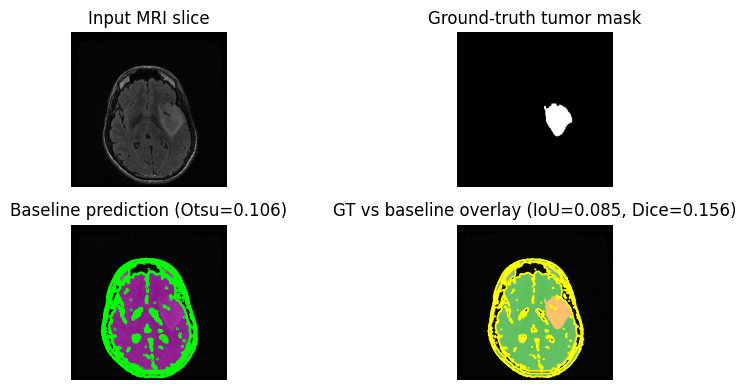


📝 Observation: Otsu thresholding typically OVER-segments because it marks
   ALL bright regions as positive — including skull, ventricles, and artifacts.
   This is why we need a LEARNED model that understands anatomical context.


In [59]:
# ============================================================================
# 2.1 Evaluate Otsu Baseline on a Random Sample
# ============================================================================

# Pick a random image-mask pair to demonstrate the baseline
ind_val = random.randint(0, len(pairs) - 1)
image_path, mask_path = pairs[ind_val]
print(f"Image: {os.path.basename(image_path)}")
print(f"Mask:  {os.path.basename(mask_path)}")

# ── Load and preprocess the image ──
# Convert to grayscale and normalize pixel values to [0, 1] range
image = np.array(Image.open(image_path).convert("L"), dtype=np.float32) / 255.0

# ── Load the ground-truth mask ──
# The mask is binary: white (255) = tumor, black (0) = background
mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
gt = mask > 0  # Convert to boolean array (True = tumor pixel)

# ── Apply Otsu thresholding as our baseline ──
thr = otsu_threshold(image)
pred = image > thr  # Pixels brighter than threshold are predicted as "tumor"

# ── Compute evaluation metrics ──
# IoU (Intersection over Union): strict measure — penalizes both FP and FN equally
# IoU = |Pred ∩ GT| / |Pred ∪ GT|
iou = np.logical_and(pred, gt).sum() / np.logical_or(pred, gt).sum()

# Dice coefficient: equivalent to F1-score for binary segmentation
# Dice = 2·|Pred ∩ GT| / (|Pred| + |GT|)
dice = (2 * np.logical_and(pred, gt).sum()) / (pred.sum() + gt.sum())

print(f"\nOtsu threshold: {thr:.4f}")
print(f"IoU:  {iou:.4f}")
print(f"Dice: {dice:.4f}")

# ── Visualize the results ──
fig, axes = plt.subplots(2, 2, figsize=(10, 4))

# Panel 1: Raw MRI slice
axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Input MRI slice")
axes[0, 0].axis("off")

# Panel 2: Expert-annotated ground truth
axes[0, 1].imshow(gt, cmap="gray")
axes[0, 1].set_title("Ground-truth tumor mask")
axes[0, 1].axis("off")

# Panel 3: Our baseline prediction with Otsu
axes[1, 0].imshow(image, cmap="gray")
axes[1, 0].imshow(np.ma.masked_where(~pred, pred), cmap="spring", alpha=0.45)
axes[1, 0].contour(pred.astype(np.uint8), levels=[0.5], colors="lime", linewidths=1.8)
axes[1, 0].set_title(f"Baseline prediction (Otsu={thr:.3f})")
axes[1, 0].axis("off")

# Panel 4: GT vs prediction overlay
# Red channel = ground truth, Green channel = prediction
# Yellow overlap = correct, Red only = missed (FN), Green only = false alarm (FP)
overlay = np.stack([image, image, image], axis=-1)
overlay[..., 0] = np.where(gt, 1.0, overlay[..., 0])       # Red for GT
overlay[..., 1] = np.where(pred, 1.0, overlay[..., 1])     # Green for prediction
axes[1, 1].imshow(overlay)
axes[1, 1].imshow(np.ma.masked_where(~pred, pred), cmap="spring", alpha=0.25)
axes[1, 1].contour(pred.astype(np.uint8), levels=[0.5], colors="yellow", linewidths=1.2)
axes[1, 1].set_title(f"GT vs baseline overlay (IoU={iou:.3f}, Dice={dice:.3f})")
axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig('images/otsu_res_index_{}.png'.format(ind_val), dpi=150)
plt.show()

# ── Key observation for students ──
print("\n📝 Observation: Otsu thresholding typically OVER-segments because it marks")
print("   ALL bright regions as positive — including skull, ventricles, and artifacts.")
print("   This is why we need a LEARNED model that understands anatomical context.")

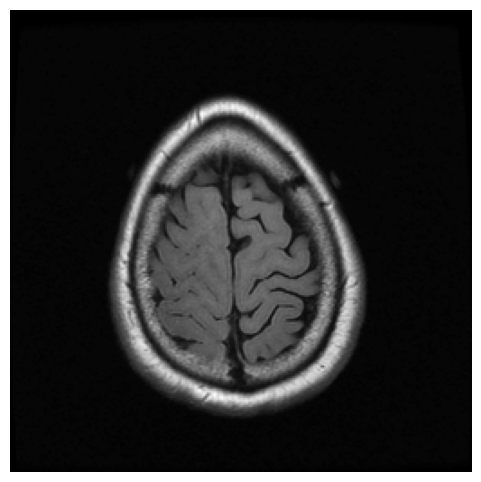

💾 Saved sample MRI slice as 'images/input_mri_slice_1667.png'


In [42]:
# ============================================================================
# 2.2 Save a Sample MRI Slice for Reference
# ============================================================================
# This saved image can be used later to test the web application

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.savefig(f"images/input_mri_slice_{ind_val}.png", bbox_inches="tight", pad_inches=0)
plt.show()
print(f"💾 Saved sample MRI slice as 'images/input_mri_slice_{ind_val}.png'")

---

## Part 3: Supervised Deep Learning — Residual SE U-Net

### Why move beyond thresholding?

| Limitation of Otsu | How deep learning helps |
|---|---|
| No spatial context — treats each pixel independently | Convolutional layers learn local and global patterns |
| Cannot distinguish tumor from other bright structures | Trained on labeled data to recognize tumor-specific features |
| Single global threshold for entire image | Per-pixel probability maps with varying confidence |
| No notion of shape, texture, or boundary | Deep features learn anatomical priors |

### What we'll build

A **Residual SE U-Net** — a modern variant of the classic U-Net architecture with two key enhancements:

1. **Residual connections** within each block (inspired by ResNet) — stabilize training of deeper networks
2. **Squeeze-and-Excitation (SE) attention** — let the model learn which feature channels are most informative

### Medical framing
- **Input:** a 2D MRI slice (128×128 grayscale)
- **Output:** a per-pixel tumor probability map
- **Clinical analogy:** semi-automatic contour support for lesion delineation (educational only)

### 3.1 Training Strategy — Why Each Component Matters

> 💡 Each technique below addresses a **specific challenge** in medical image segmentation. Understanding *why* each component exists is as important as knowing *how* it works.

#### 1) Loss Design: BCE + Focal-Tversky

**Challenge:** Extreme class imbalance — tumor pixels may be <5% of the image.

The training loss combines two complementary objectives:

$$
\mathcal{L}_{\text{total}} = \lambda_{\text{BCE}}\,\mathcal{L}_{\text{BCE}} + \lambda_{\text{FT}}\,\mathcal{L}_{\text{Focal-Tversky}}
$$

where $\lambda_{\text{BCE}}=0.3$ and $\lambda_{\text{FT}}=0.7$ (Focal-Tversky gets more weight).

**Weighted BCE** (probabilistic calibration):

$$
\mathcal{L}_{\text{BCE}} = -\frac{1}{N}\sum_i\Big[w_{+}\,y_i\log\sigma(z_i) + (1-y_i)\log(1-\sigma(z_i))\Big]
$$

**Tversky Index** (asymmetric overlap):

$$
\text{TI} = \frac{TP + \varepsilon}{TP + \alpha\,FP + \beta\,FN + \varepsilon}
$$

**Focal-Tversky Loss** (focus on hard cases):

$$
\mathcal{L}_{\text{Focal-Tversky}} = (1-\text{TI})^{\gamma}
$$

With $\alpha=0.7$, $\beta=0.3$, $\gamma=1.33$: the loss **penalizes false negatives more strongly** — missing tumor tissue is costlier than false alarms in many clinical contexts.

#### 2) Weighted Sampling

**Challenge:** Most MRI slices are tumor-free, causing the model to learn "predict background everywhere."

`WeightedRandomSampler` oversamples tumor-containing slices so the model sees a balanced mix during training.

#### 3) EMA (Exponential Moving Average)

**Challenge:** Noisy gradient updates can cause unstable model behavior.

EMA maintains a smoothed copy of model weights:

$$
\theta^{\text{EMA}}_t = d\,\theta^{\text{EMA}}_{t-1} + (1-d)\,\theta_t
$$

where $d=0.995$. Think of EMA as a "temporal low-pass filter" — it smooths out the noise from individual mini-batch updates, often producing better generalization.

#### 4) Test-Time Augmentation (TTA)

**Challenge:** Model predictions can vary with image orientation.

At inference, we predict on 4 flipped versions of the same image and average the results:

$$
\hat{p}(x)=\frac{1}{K}\sum_{k=1}^{K} T_k^{-1}\Big( f\big(T_k(x)\big) \Big)
$$

where $K=4$ (identity + horizontal + vertical + both flips). TTA produces smoother, more robust tumor contours.

#### 5) Early Stopping

**Challenge:** Overfitting — training too long memorizes the training set.

We stop training when validation loss hasn't improved for several consecutive epochs, and restore the best checkpoint.

### 3.2 Symbol Glossary — Quick Reference

Use this table as a reference while reading the formulas and code.

#### Data & Prediction
| Symbol | Meaning | Code equivalent |
|---|---|---|
| $x$ | Input MRI slice | `image_chw` |
| $y$, $y_i$ | Ground-truth mask (binary) | `masks_batch` |
| $z_i$ | Raw model output (logit) at pixel $i$ | `logits` |
| $\sigma(z_i)$ | Predicted probability after sigmoid | `torch.sigmoid(logits)` |
| $\hat{p}(x)$ | Averaged probability map (after TTA) | `mean_prob` |
| $\hat{y}$ | Final binary prediction after thresholding | `pred` |

#### Loss Parameters
| Symbol | Value | Meaning | Code equivalent |
|---|---|---|---|
| $\lambda_{\text{BCE}}$ | 0.3 | BCE weight in total loss | `BCE_WEIGHT` |
| $\lambda_{\text{FT}}$ | 0.7 | Focal-Tversky weight in total loss | `FOCAL_TVERSKY_WEIGHT` |
| $\alpha$ | 0.7 | FP penalty in Tversky | `TVERSKY_ALPHA` |
| $\beta$ | 0.3 | FN penalty in Tversky | `TVERSKY_BETA` |
| $\gamma$ | 1.33 | Focal exponent (harder cases → more focus) | `FOCAL_GAMMA` |
| $w_+$ | auto | Positive class weight for BCE | `pos_weight_value` |

#### Overlap Metrics
| Symbol | Formula | Interpretation |
|---|---|---|
| $TP$ | Tumor pixels correctly predicted as tumor | ✅ Correct detection |
| $FP$ | Healthy pixels wrongly predicted as tumor | ⚠️ False alarm |
| $FN$ | Tumor pixels missed by the model | ❌ Missed tumor — often the most dangerous clinically |

#### Training Techniques
| Symbol | Meaning | Code equivalent |
|---|---|---|
| $\theta_t$ | Model weights at step $t$ | `unet.state_dict()` |
| $\theta^{\text{EMA}}_t$ | Smoothed EMA weights | `ema.shadow` |
| $d$ | EMA decay (0.995 = strong smoothing) | `EMA_DECAY` |
| $T_k$ / $T_k^{-1}$ | Flip transform / its inverse | `torch.flip(x, dims=...)` |
| $K$ | Number of TTA views (4) | `tta_dims` |
| $\tau$ | Threshold for binary mask | `best_threshold` |

### 3.3 U-Net Architecture — How It Works

The **U-Net** is the workhorse of medical image segmentation. Its key insight: combine **high-level semantic information** (what is a tumor?) with **fine-grained spatial detail** (where exactly is the boundary?).

```
                    ENCODER                         DECODER
              (capture context)              (recover spatial detail)
              
    Input ──▶ [Conv-Conv-SE] ──────────────────▶ [Conv-Conv-SE] ──▶ Output
                    │          skip connection          ▲
                    ▼ MaxPool                   UpConv  │
              [Conv-Conv-SE] ──────────────────▶ [Conv-Conv-SE]
                    │          skip connection          ▲
                    ▼ MaxPool                   UpConv  │
              [Conv-Conv-SE] ──────────────────▶ [Conv-Conv-SE]
                    │          skip connection          ▲
                    ▼ MaxPool                   UpConv  │
              [Conv-Conv-SE] ──────────────────▶ [Conv-Conv-SE]
                    │          skip connection          ▲
                    ▼ MaxPool                   UpConv  │
                         [BOTTLENECK: Conv-Conv-SE]
```

#### Why this "U" shape?
- **Encoder path:** progressively downsamples → larger receptive field → understands "big picture" context
- **Decoder path:** progressively upsamples → recovers spatial resolution → precise pixel-level output
- **Skip connections:** concatenate encoder features directly to decoder — prevents loss of fine detail

#### Our enhancements over vanilla U-Net

| Component | What it does | Why it helps |
|---|---|---|
| **Residual connections** | Add input directly to output within each block | Stabilizes gradient flow, enables deeper networks |
| **SE (Squeeze-and-Excitation)** | Learn per-channel importance weights | Amplify tumor-relevant features, suppress noise |
| **Dropout** (increasing by depth) | Randomly zero out feature maps during training | Regularization — prevents overfitting on small datasets |
| **Batch Normalization** | Normalize activations within each mini-batch | Faster, more stable training |

### 3.4 Channel Flow Diagram

This shows exactly how data dimensions change through the network:

```
Input MRI slice (1 × 128 × 128)               ← 1 channel = grayscale
        │
        ▼
Encoder:
  E1: ResidualSEBlock(1   →  48)      →  48 × 128 × 128    ← low-level edges/textures
  ↓ MaxPool(2)
  E2: ResidualSEBlock(48  →  96)      →  96 ×  64 ×  64    ← local patterns
  ↓ MaxPool(2)
  E3: ResidualSEBlock(96  → 192)      → 192 ×  32 ×  32    ← regional features
  ↓ MaxPool(2)
  E4: ResidualSEBlock(192 → 384)      → 384 ×  16 ×  16    ← high-level semantics
  ↓ MaxPool(2)

Bottleneck:
  ResidualSEBlock(384 → 768)          → 768 ×   8 ×   8    ← most abstract representation

Decoder:
  UpConv(768→384), concat(E4)         → 768 ×  16 ×  16    ← skip connection doubles channels
  D4: ResidualSEBlock(768 → 384)      → 384 ×  16 ×  16

  UpConv(384→192), concat(E3)         → 384 ×  32 ×  32
  D3: ResidualSEBlock(384 → 192)      → 192 ×  32 ×  32

  UpConv(192→ 96), concat(E2)         → 192 ×  64 ×  64
  D2: ResidualSEBlock(192 →  96)      →  96 ×  64 ×  64

  UpConv( 96→ 48), concat(E1)         →  96 × 128 × 128
  D1: ResidualSEBlock( 96 →  48)      →  48 × 128 × 128

Segmentation head:
  Conv1×1(48 → 1)                     → logits (1 × 128 × 128)
  Sigmoid                             → probability map [0, 1]
  Threshold (τ)                       → binary tumor mask {0, 1}
```

> 📐 **Notice the symmetry:** the decoder mirrors the encoder perfectly. Each skip connection bridges features from the same spatial resolution.

### 3.5 Full Training & Inference Pipeline

```
┌─── DATA PREPARATION ──────────────────────────────────────────────────┐
│  LGG MRI dataset → pair matching → train/val split (balanced)        │
│  75% non-empty tumor slices in training → avoid background bias      │
└─────────────────────────────────────────────────────────────┬─────────┘
                                                              │
┌─── TRAINING LOOP ───────────────────────────────────────────▼─────────┐
│  For each epoch:                                                      │
│    1. Augment: random flips + gamma correction                       │
│    2. Weighted sampling: oversample tumor slices                     │
│    3. Forward pass through Residual SE U-Net                         │
│    4. Compute loss = 0.3·BCE + 0.7·Focal-Tversky                    │
│    5. Backprop + AdamW optimizer step                                │
│    6. Gradient clipping (max_norm=1.0)                               │
│    7. EMA update (decay=0.995)                                       │
│    8. Validation loss check → early stopping (patience=5)            │
│    9. Save best EMA weights                                          │
└─────────────────────────────────────────────────────────────┬─────────┘
                                                              │
┌─── INFERENCE ───────────────────────────────────────────────▼─────────┐
│  1. Load best EMA checkpoint                                         │
│  2. TTA: predict on 4 flipped versions → average probabilities       │
│  3. Grid-search optimal threshold on validation set                  │
│  4. Binary mask = probability > threshold                            │
│  5. Compute IoU/Dice per slice and per patient                       │
└───────────────────────────────────────────────────────────────────────┘
```

> 🎯 **Key insight:** each pipeline stage addresses a different risk — imbalance handling, overfitting prevention, prediction stability, and fair evaluation.

In [43]:
# ============================================================================
# 4.1 Imports & Training Configuration
# ============================================================================
# All hyperparameters are defined here for easy experimentation.
# Try changing these values and observing the effect on training!

import copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ── Image settings ──
IMG_SIZE = 128          # Resize all images to 128×128 (trade-off: detail vs. speed)
MAX_TRAIN = 512         # Maximum training samples (cap for faster iteration)
MAX_VAL = 96            # Maximum validation samples

# ── Training hyperparameters ──
BATCH_SIZE = 12         # Number of images per gradient update
EPOCHS = 14             # Maximum training epochs (early stopping may stop sooner)
LR = 8e-4               # Learning rate (AdamW optimizer)

# ── Loss function tuning ──
# These control the balance between different types of errors
TVERSKY_ALPHA = 0.7     # Penalty for false positives (higher = stricter on FP)
TVERSKY_BETA = 0.3      # Penalty for false negatives (lower here, but FT loss
                        #   combined with high alpha makes FN still penalized)
FOCAL_GAMMA = 1.33      # Focus more on hard-to-classify pixels
BCE_WEIGHT = 0.3        # How much of the total loss comes from BCE
FOCAL_TVERSKY_WEIGHT = 0.7  # How much comes from Focal-Tversky

# ── Regularization ──
EMA_DECAY = 0.995       # Exponential Moving Average decay (closer to 1 = smoother)

# ── Device selection ──
# Automatically use GPU if available, otherwise fall back to CPU
unet_device = (
    "cuda" if torch.cuda.is_available()
    else ("mps" if torch.mps.is_available() else "cpu")
)
print(f"🖥️  Training device: {unet_device}")

🖥️  Training device: cuda


### 4.2 Dataset Class — Loading and Augmenting MRI Data

The `MRISegmentationDataset` class handles:
1. **Loading** images and masks from disk
2. **Resizing** to a uniform size (128×128)
3. **Augmentation** during training — random flips and gamma correction to artificially increase data diversity

> 💡 **Why augment?** Medical datasets are small. Data augmentation creates slightly different views of the same image, reducing overfitting and improving generalization.

In [44]:
# ============================================================================
# 4.2 Dataset Class
# ============================================================================

class MRISegmentationDataset(Dataset):
    """
    PyTorch Dataset for loading MRI image-mask pairs.
    
    Each item returns:
        image: torch.Tensor of shape [1, H, W] (grayscale, normalized to [0, 1])
        mask:  torch.Tensor of shape [1, H, W] (binary: 0 = background, 1 = tumor)
    """
    
    def __init__(self, pair_list, image_size=128, augment=False):
        self.pairs = pair_list
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, mask_p = self.pairs[idx]
        
        # Load image as grayscale, resize to uniform dimensions
        image = Image.open(img_p).convert("L").resize(
            (self.image_size, self.image_size), Image.BILINEAR
        )
        # Load mask — use NEAREST interpolation to preserve binary values
        mask = Image.open(mask_p).convert("L").resize(
            (self.image_size, self.image_size), Image.NEAREST
        )

        # Convert to numpy: image → [0, 1] float, mask → binary {0, 1}
        image = np.array(image, dtype=np.float32) / 255.0
        mask = (np.array(mask, dtype=np.uint8) > 0).astype(np.float32)

        # ── Data augmentation (training only) ──
        if self.augment:
            # Random horizontal flip (50% chance)
            if random.random() < 0.5:
                image = np.fliplr(image).copy()
                mask = np.fliplr(mask).copy()
            
            # Random vertical flip (50% chance)
            if random.random() < 0.5:
                image = np.flipud(image).copy()
                mask = np.flipud(mask).copy()
            
            # Random gamma correction (25% chance) — simulates brightness variations
            # Gamma < 1: brighter image, Gamma > 1: darker image
            if random.random() < 0.25:
                gamma = random.uniform(0.8, 1.2)
                image = np.clip(image ** gamma, 0.0, 1.0)

        # Convert to PyTorch tensors with channel dimension: [1, H, W]
        image = torch.from_numpy(image).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)
        return image, mask


print(f"✅ MRISegmentationDataset class defined")

✅ MRISegmentationDataset class defined


### 4.3 Building Blocks — SE Block and Residual SE Block

Before building the full U-Net, we define its fundamental building blocks:

1. **SEBlock (Squeeze-and-Excitation):** Learns to **reweight feature channels** based on global context. Think of it as the model asking: "which feature channels are most useful right now?"
   
   ```
   Input features → Global Avg Pool → FC → ReLU → FC → Sigmoid → Scale input
                     (squeeze)          (excitation)              (reweight)
   ```

2. **ResidualSEBlock:** Two convolutions + batch norm + SE attention + residual skip. The skip connection adds the input directly to the output, making optimization easier.

In [45]:
# ============================================================================
# 4.3 Building Blocks: SEBlock and ResidualSEBlock
# ============================================================================

class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation Block (Hu et al., 2018).
    
    Channel attention mechanism that:
    1. SQUEEZE: Global average pooling → one number per channel (what's important globally?)
    2. EXCITATION: Two FC layers learn channel importance weights
    3. SCALE: Multiply input by learned importance → amplify useful features, suppress noise
    
    Args:
        channels: Number of input/output channels
        reduction: Compression ratio for the bottleneck (default 8)
    """
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)  # At least 8 hidden units
        self.pool = nn.AdaptiveAvgPool2d(1)     # Squeeze: H×W → 1×1
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1),   # Compress
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1),   # Expand back
            nn.Sigmoid(),                                  # Output weights in [0, 1]
        )

    def forward(self, x):
        # scale has shape [B, C, 1, 1] — one weight per channel
        scale = self.fc(self.pool(x))
        return x * scale  # Element-wise multiplication (channel reweighting)


class ResidualSEBlock(nn.Module):
    """
    Residual block with SE attention — the core building block of our U-Net.
    
    Architecture:
        Input → Conv3×3 → BN → ReLU → Dropout → Conv3×3 → BN → SE → + Identity → ReLU → Output
                                                                      ↑
                                                            Skip connection (1×1 conv if channels change)
    
    The residual (skip) connection ensures that the block can always pass information
    through unchanged, making the network easier to optimize.
    """
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        # Two 3×3 convolutions with batch normalization
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        
        # Channel attention
        self.se = SEBlock(out_ch)
        self.relu = nn.ReLU(inplace=True)
        
        # Dropout for regularization (prevents overfitting)
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        # Skip connection: if input and output channels differ, 
        # use a 1×1 conv to match dimensions
        if in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)                # Save input (possibly transformed)
        
        out = self.relu(self.bn1(self.conv1(x)))  # Conv → BN → ReLU
        out = self.drop(out)                       # Dropout (training only)
        out = self.bn2(self.conv2(out))            # Conv → BN
        out = self.se(out)                         # Channel attention (SE)
        out = out + identity                       # Residual addition
        out = self.relu(out)                       # Final activation
        
        return out


print("✅ SEBlock and ResidualSEBlock defined")

✅ SEBlock and ResidualSEBlock defined


### 4.4 The SmallUNet Model

Now we assemble the full U-Net from our building blocks. The name "SmallUNet" refers to using `base_ch=48` (moderate channel count) rather than the standard 64, keeping the model compact for faster training.

**Parameter count:** ~17.5M parameters — large enough to learn complex tumor patterns, small enough to train on a single GPU.

In [46]:
# ============================================================================
# 4.4 SmallUNet — The Complete Model
# ============================================================================

class SmallUNet(nn.Module):
    """
    Residual SE U-Net for binary tumor segmentation.
    
    Architecture overview:
        Encoder: 4 stages of ResidualSEBlock + MaxPool (increasing channels)
        Bottleneck: ResidualSEBlock at lowest resolution
        Decoder: 4 stages of UpConv + Concat(skip) + ResidualSEBlock (decreasing channels)
        Head: 1×1 Conv → single-channel logit output
    
    Args:
        base_ch: Base number of channels (default 48). All other channel  
                 counts are multiples: 48 → 96 → 192 → 384 → 768
    """

    def __init__(self, base_ch=48):
        super().__init__()
        self.pool = nn.MaxPool2d(2)  # Halves spatial dimensions

        # ── ENCODER: progressively extract deeper features ──
        # Notice dropout increases with depth (more regularization in deeper layers)
        self.enc1 = ResidualSEBlock(1, base_ch, dropout=0.0)            # 1 ch → 48 ch
        self.enc2 = ResidualSEBlock(base_ch, base_ch * 2, dropout=0.05) # 48 → 96
        self.enc3 = ResidualSEBlock(base_ch * 2, base_ch * 4, dropout=0.1)   # 96 → 192
        self.enc4 = ResidualSEBlock(base_ch * 4, base_ch * 8, dropout=0.15)  # 192 → 384

        # ── BOTTLENECK: highest-level representation ──
        self.bottleneck = ResidualSEBlock(base_ch * 8, base_ch * 16, dropout=0.2)  # 384 → 768

        # ── DECODER: progressively recover spatial detail ──
        # Each stage: UpConv (double resolution) → Concat (skip features) → ResidualSEBlock
        self.up4 = nn.ConvTranspose2d(base_ch * 16, base_ch * 8, kernel_size=2, stride=2)
        self.dec4 = ResidualSEBlock(base_ch * 16, base_ch * 8, dropout=0.1)  # 768 → 384

        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, kernel_size=2, stride=2)
        self.dec3 = ResidualSEBlock(base_ch * 8, base_ch * 4, dropout=0.1)   # 384 → 192

        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = ResidualSEBlock(base_ch * 4, base_ch * 2, dropout=0.05)  # 192 → 96

        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = ResidualSEBlock(base_ch * 2, base_ch, dropout=0.0)       # 96 → 48

        # ── SEGMENTATION HEAD: 1×1 conv to produce single logit per pixel ──
        self.head = nn.Conv2d(base_ch, 1, kernel_size=1)

    def forward(self, x):
        # ── Encoder path (save features for skip connections) ──
        e1 = self.enc1(x)              # 128×128
        e2 = self.enc2(self.pool(e1))  #  64×64
        e3 = self.enc3(self.pool(e2))  #  32×32
        e4 = self.enc4(self.pool(e3))  #  16×16

        # ── Bottleneck ──
        b = self.bottleneck(self.pool(e4))  # 8×8

        # ── Decoder path (upsample + concatenate skip features) ──
        d4 = self.up4(b)                           # 16×16
        d4 = self.dec4(torch.cat([d4, e4], dim=1)) # concat along channel dim

        d3 = self.up3(d4)                           # 32×32
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)                           # 64×64
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)                           # 128×128
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        # Output raw logits (sigmoid is applied in the loss or at inference)
        return self.head(d1)


# Quick test: verify the model produces the expected output shape
_test_model = SmallUNet(base_ch=48)
_test_input = torch.randn(1, 1, IMG_SIZE, IMG_SIZE)
_test_output = _test_model(_test_input)
print(f"✅ SmallUNet defined")
print(f"   Input shape:  {list(_test_input.shape)}")
print(f"   Output shape: {list(_test_output.shape)}")
print(f"   Parameters:   {sum(p.numel() for p in _test_model.parameters()):,}")
del _test_model, _test_input, _test_output  # Free memory

✅ SmallUNet defined
   Input shape:  [1, 1, 128, 128]
   Output shape: [1, 1, 128, 128]
   Parameters:   18,496,601


### 4.5 Loss Functions

We define two loss components that work together:

| Loss | Role | Handles |
|---|---|---|
| **Weighted BCE** | Per-pixel binary cross-entropy with class weights | Probabilistic calibration under imbalance |
| **Focal-Tversky** | Overlap-based loss with focal modulation | Penalizes FN more heavily, focuses on hard pixels |

The combined loss provides complementary training signals — BCE for well-calibrated probabilities, Focal-Tversky for overlap quality.

In [47]:
# ============================================================================
# 4.5 Loss Functions
# ============================================================================

def dice_loss_from_logits(logits, target, eps=1e-6):
    """
    Soft Dice loss computed directly from logits.
    
    Dice = 2·|Pred ∩ GT| / (|Pred| + |GT|)
    Loss = 1 - Dice
    
    Note: This function is defined for reference but not used in the 
    combined loss below (Focal-Tversky generalizes Dice).
    """
    probs = torch.sigmoid(logits)
    inter = (probs * target).sum(dim=(1, 2, 3))
    denom = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2.0 * inter + eps) / (denom + eps)
    return 1.0 - dice.mean()


def focal_tversky_loss_from_logits(logits, target, alpha=0.7, beta=0.3,
                                     gamma=1.33, eps=1e-6):
    """
    Focal Tversky loss — an asymmetric overlap loss that focuses on hard cases.
    
    Tversky Index: TI = (TP + ε) / (TP + α·FP + β·FN + ε)
    Focal Tversky:  L = (1 - TI)^γ
    
    Key behavior:
    - α > β → penalizes false positives more
    - γ > 1 → focuses training on harder samples (similar to Focal Loss idea)
    - When α = β = 0.5 and γ = 1 → equivalent to Dice loss
    """
    probs = torch.sigmoid(logits)
    
    # Compute soft TP, FP, FN (differentiable approximation)
    tp = (probs * target).sum(dim=(1, 2, 3))           # True positives
    fp = (probs * (1.0 - target)).sum(dim=(1, 2, 3))   # False positives
    fn = ((1.0 - probs) * target).sum(dim=(1, 2, 3))   # False negatives
    
    tversky = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
    return ((1.0 - tversky) ** gamma).mean()


def compute_segmentation_loss(logits, target):
    """
    Combined segmentation loss = 0.3·BCE + 0.7·Focal-Tversky
    
    This combination provides two complementary training signals:
    - BCE: pixel-wise probability calibration (good gradients for all pixels)
    - Focal-Tversky: overlap-focused, FN-sensitive (good for small tumors)
    """
    bce_loss = bce(logits, target)
    ft_loss = focal_tversky_loss_from_logits(
        logits, target,
        alpha=TVERSKY_ALPHA,
        beta=TVERSKY_BETA,
        gamma=FOCAL_GAMMA,
    )
    return BCE_WEIGHT * bce_loss + FOCAL_TVERSKY_WEIGHT * ft_loss


print("✅ Loss functions defined: Dice, Focal-Tversky, Combined")

✅ Loss functions defined: Dice, Focal-Tversky, Combined


### 4.6 EMA and Test-Time Augmentation (TTA)

Two techniques that improve inference quality without changing the model architecture:

**EMA (Exponential Moving Average):**
- Keeps a running smoothed average of model weights during training
- Often generalizes better than the raw "last epoch" weights
- Think of it as a "best-of" average rather than a snapshot

**TTA (Test-Time Augmentation):**
- At inference, predict on 4 versions of the image (original + 3 flips)
- Average the predictions → smoother, more robust tumor contours
- Costs 4× compute but significantly reduces boundary noise

In [48]:
# ============================================================================
# 4.6 EMA (Exponential Moving Average) and TTA (Test-Time Augmentation)
# ============================================================================

class ModelEMA:
    """
    Exponential Moving Average of model parameters.
    
    Maintains a shadow copy of weights updated as:
        θ_EMA(t) = decay · θ_EMA(t-1) + (1 - decay) · θ(t)
    
    With decay=0.995, the EMA weights represent roughly a moving average
    of the last ~200 gradient updates (1 / (1 - 0.995) = 200).
    """
    def __init__(self, model, decay=0.995):
        self.decay = decay
        # Initialize shadow weights as a copy of the model's current weights
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    def update(self, model):
        """Update shadow weights after each optimizer step."""
        for key, value in model.state_dict().items():
            if value.dtype.is_floating_point:
                # Weighted average: shadow = decay * shadow + (1 - decay) * current
                self.shadow[key].mul_(self.decay).add_(value.detach(), alpha=1.0 - self.decay)
            else:
                # Non-floating point params (e.g., batch norm running counts) — just copy
                self.shadow[key] = value.detach().clone()


def predict_prob_with_tta(model, image_chw, device, use_tta=True):
    """
    Predict a tumor probability map with optional Test-Time Augmentation.
    
    TTA strategy (4-fold flip):
        1. Original image         → predict → probabilities
        2. Horizontal flip        → predict → flip back probabilities  
        3. Vertical flip          → predict → flip back probabilities
        4. Both flips             → predict → flip back probabilities
        Average all 4 → final probability map
    
    Args:
        model: trained U-Net model
        image_chw: [1, H, W] tensor (single image, single channel)
        device: 'cuda', 'mps', or 'cpu'
        use_tta: if False, only do a single forward pass (4× faster)
    
    Returns:
        prob_map: numpy array of shape [H, W] with values in [0, 1]
    """
    x = image_chw.unsqueeze(0).to(device)  # Add batch dimension: [1, 1, H, W]
    
    # Define flip transforms: None = identity, (-1,) = horizontal, (-2,) = vertical, (-1,-2) = both
    tta_dims = [None, (-1,), (-2,), (-1, -2)] if use_tta else [None]
    probs = []

    with torch.no_grad():  # No gradients needed at inference time
        for dims in tta_dims:
            # Apply augmentation (flip)
            x_aug = torch.flip(x, dims=dims) if dims is not None else x
            
            # Forward pass
            logits = model(x_aug)
            prob = torch.sigmoid(logits)
            
            # Undo the flip so all predictions are aligned
            if dims is not None:
                prob = torch.flip(prob, dims=dims)
            
            probs.append(prob)

    # Average all predictions → smoother, more robust result
    mean_prob = torch.stack(probs, dim=0).mean(dim=0)
    return mean_prob[0, 0].cpu().numpy()  # Return as [H, W] numpy array


print("✅ ModelEMA and predict_prob_with_tta defined")

✅ ModelEMA and predict_prob_with_tta defined


### 4.7 Data Preparation — Train/Val Split and Weighted Sampling

Good data preparation is critical for medical imaging:

1. **Balanced split:** We ensure the training set has ~75% tumor-containing slices (instead of the natural ~30%) so the model sees enough positive examples
2. **Weighted sampler:** Even within training, we oversample tumor slices so each mini-batch has a balanced mix
3. **BCE pos_weight:** Computed from actual pixel ratios to further address imbalance at the pixel level

> 💡 **Three levels of imbalance handling:** dataset composition → batch sampling → loss weighting

In [49]:
# ============================================================================
# 4.7 Data Preparation: Train/Val Split + Weighted Sampling
# ============================================================================

def has_foreground(mask_path):
    """Check if a mask file contains any tumor pixels."""
    m = np.array(Image.open(mask_path).convert("L"), dtype=np.uint8)
    return bool((m > 0).any())


# ── Step 1: Shuffle and separate tumor vs. empty slices ──
rng = random.Random(42)  # Fixed seed for reproducibility
pairs_shuffled = pairs.copy()
rng.shuffle(pairs_shuffled)

non_empty_pairs = [p for p in pairs_shuffled if has_foreground(p[1])]
empty_pairs = [p for p in pairs_shuffled if not has_foreground(p[1])]

print(f"Dataset composition:")
print(f"  Total pairs:      {len(pairs_shuffled)}")
print(f"  With tumor:       {len(non_empty_pairs)} ({100 * len(non_empty_pairs) / len(pairs_shuffled):.1f}%)")
print(f"  Without tumor:    {len(empty_pairs)} ({100 * len(empty_pairs) / len(pairs_shuffled):.1f}%)")

# ── Step 2: Build a balanced train/val split ──
# Training: ~75% tumor-containing slices (enriched for learning)
n_train_non_empty = min(len(non_empty_pairs), int(MAX_TRAIN * 0.75))
n_train_empty = min(len(empty_pairs), MAX_TRAIN - n_train_non_empty)

train_pairs = non_empty_pairs[:n_train_non_empty] + empty_pairs[:n_train_empty]
rng.shuffle(train_pairs)

# Validation: remaining samples (representative of real distribution)
remaining_non_empty = non_empty_pairs[n_train_non_empty:]
remaining_empty = empty_pairs[n_train_empty:]
val_pairs = (
    remaining_non_empty[:MAX_VAL] 
    if len(remaining_non_empty) >= MAX_VAL 
    else remaining_non_empty + remaining_empty[:MAX_VAL - len(remaining_non_empty)]
)

print(f"\nSplit results:")
print(f"  Train samples: {len(train_pairs)}")
print(f"  Val samples:   {len(val_pairs)}")

# ── Step 3: Create datasets ──
train_ds = MRISegmentationDataset(train_pairs, image_size=IMG_SIZE, augment=True)
val_ds = MRISegmentationDataset(val_pairs, image_size=IMG_SIZE, augment=False)

# ── Step 4: Weighted sampling (oversample tumor slices in training) ──
# Each batch will have roughly 50% tumor slices and 50% empty slices
train_is_foreground = [1 if has_foreground(mask_p) else 0 for _, mask_p in train_pairs]
fg_count = max(sum(train_is_foreground), 1)
bg_count = max(len(train_is_foreground) - fg_count, 1)
fg_weight = 0.5 / fg_count  # Weight per tumor slice
bg_weight = 0.5 / bg_count  # Weight per empty slice
sample_weights = [fg_weight if is_fg else bg_weight for is_fg in train_is_foreground]
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Create data loaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# ── Step 5: Estimate pixel-level class imbalance for BCE weighting ──
# Count tumor vs. background pixels across the training set
print("\nComputing pixel-level class balance...")
pos_pixels = 0.0
total_pixels = 0.0
for _, m in train_ds:
    pos_pixels += float(m.sum().item())
    total_pixels += float(m.numel())

neg_pixels = max(total_pixels - pos_pixels, 1.0)
pos_pixels = max(pos_pixels, 1.0)
pos_weight_value = min(20.0, max(1.0, neg_pixels / pos_pixels))
print(f"  Tumor pixels:     {pos_pixels:.0f} / {total_pixels:.0f} ({100 * pos_pixels / total_pixels:.2f}%)")
print(f"  BCE pos_weight:   {pos_weight_value:.2f} (upweights rare tumor pixels in the loss)")

Dataset composition:
  Total pairs:      7858
  With tumor:       2746 (34.9%)
  Without tumor:    5112 (65.1%)

Split results:
  Train samples: 512
  Val samples:   96

Computing pixel-level class balance...
  Tumor pixels:     184728 / 8388608 (2.20%)
  BCE pos_weight:   20.00 (upweights rare tumor pixels in the loss)


### 4.8 Model Initialization

Now we create the model, optimizer, learning rate scheduler, and EMA.

| Component | Choice | Why |
|---|---|---|
| **Optimizer** | AdamW | Stable convergence with built-in weight decay (L2 regularization) |
| **LR Scheduler** | CosineAnnealing | Gradually reduces LR following a cosine curve — helps fine-tune near convergence |
| **EMA decay** | 0.995 | Strong smoothing — averages roughly the last 200 gradient steps |

In [50]:
# ============================================================================
# 4.8 Model Initialization
# ============================================================================

# Create model and move to GPU/MPS/CPU
unet = SmallUNet(base_ch=64).to(unet_device)

# AdamW optimizer — Adam with decoupled weight decay (better regularization)
optimizer = torch.optim.AdamW(unet.parameters(), lr=LR, weight_decay=1e-3)

# Cosine annealing: LR starts at LR, decays smoothly to ~0 over EPOCHS
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Weighted BCE loss — pos_weight upweights the rare tumor class
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], device=unet_device))

# EMA tracker — maintains smoothed model weights
ema = ModelEMA(unet, decay=EMA_DECAY)

# Track best validation performance for early stopping
best_state = None
best_val_loss = float("inf")

print(f"✅ Model initialized on {unet_device}")
print(f"   Optimizer:  AdamW (lr={LR}, weight_decay=1e-3)")
print(f"   Scheduler:  CosineAnnealing (T_max={EPOCHS})")
print(f"   EMA decay:  {EMA_DECAY}")

✅ Model initialized on cuda
   Optimizer:  AdamW (lr=0.0008, weight_decay=1e-3)
   Scheduler:  CosineAnnealing (T_max=14)
   EMA decay:  0.995


In [51]:
# ============================================================================
# 4.9 Load Pre-trained Checkpoint (Optional)
# ============================================================================
# Set load_model = True to skip training and load the best saved model.
# Set load_model = False to train from scratch.

load_model = True  # ← Change this to False if you want to train from scratch

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "unet_resse_best.pt")

loaded_checkpoint = {"threshold": 0.5}

if load_model and os.path.exists(checkpoint_path):
    print("📂 Loading best model checkpoint from disk...")
    checkpoint = torch.load(checkpoint_path, map_location=unet_device)
    
    # Load model weights
    unet.load_state_dict(checkpoint["model_state_dict"])
    
    # Load EMA weights if available
    if "ema_state_dict" in checkpoint and "ema" in globals():
        ema.shadow = {k: v.clone() for k, v in checkpoint["ema_state_dict"].items()}
    
    best_val_loss = checkpoint.get("best_val_loss", best_val_loss)
    print(f"   Validation loss:  {best_val_loss:.4f}")
    
    loaded_checkpoint = {
        "model_state_dict": checkpoint["model_state_dict"],
        "best_val_loss": best_val_loss,
        "threshold": checkpoint.get("threshold", 0.5),
    }
    print(f"   Threshold:        {loaded_checkpoint.get('threshold', 0.5):.2f}")
    print(f"✅ Checkpoint loaded successfully!")
else:
    print("🆕 No checkpoint loaded — will train from scratch in the next cell.")

📂 Loading best model checkpoint from disk...
   Validation loss:  0.2014
   Threshold:        0.35
✅ Checkpoint loaded successfully!


---

## Part 5: Training the Model

Now we put everything together and train! The training loop orchestrates all the components we defined:
- Forward pass through the U-Net
- Combined BCE + Focal-Tversky loss computation
- Backpropagation with gradient clipping
- EMA weight update
- Validation monitoring with early stopping

> ⏱️ Training typically takes **3-10 minutes** depending on your hardware. If you prefer, load the pre-trained checkpoint in cell 4.9 and skip the training cell.

In [52]:
# ============================================================================
# 5.1 Training Loop
# ============================================================================
# This is the main training loop. Each epoch:
#   1. Trains on all batches (forward → loss → backward → update weights → EMA)
#   2. Evaluates on validation set (loss only, no backprop)
#   3. Checks for improvement → saves best EMA weights
#   4. Early stopping if no improvement for EARLY_STOPPING_PATIENCE epochs
#
# Skip this cell if you loaded a pre-trained checkpoint above.

EPOCHS = 100
EARLY_STOPPING_PATIENCE = 20    # Stop if no val improvement for 20 epochs
MIN_IMPROVEMENT = 1e-2          # Minimum loss decrease to count as "improvement"

epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    try:
        # ── TRAINING PHASE ──
        unet.train()  # Enable dropout, batch norm in training mode
        train_loss = 0.0

        for images_batch, masks_batch in train_loader:
            images_batch = images_batch.to(unet_device)
            masks_batch = masks_batch.to(unet_device)

            optimizer.zero_grad()                                    # Reset gradients
            logits = unet(images_batch)                              # Forward pass
            loss = compute_segmentation_loss(logits, masks_batch)    # Compute combined loss
            loss.backward()                                          # Backpropagation
            nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)  # Prevent exploding gradients
            optimizer.step()                                         # Update weights
            ema.update(unet)                                         # Update EMA shadow weights

            train_loss += loss.item() * images_batch.size(0)

        train_loss /= max(len(train_ds), 1)

        # ── VALIDATION PHASE ──
        unet.eval()  # Disable dropout, use running stats for batch norm
        val_loss = 0.0
        with torch.no_grad():  # No gradient computation needed
            for images_batch, masks_batch in val_loader:
                images_batch = images_batch.to(unet_device)
                masks_batch = masks_batch.to(unet_device)
                logits = unet(images_batch)
                loss = compute_segmentation_loss(logits, masks_batch)
                val_loss += loss.item() * images_batch.size(0)

        val_loss /= max(len(val_ds), 1)
        scheduler.step()  # Update learning rate

        # ── EARLY STOPPING CHECK ──
        if val_loss < (best_val_loss - MIN_IMPROVEMENT):
            best_val_loss = val_loss
            best_state = copy.deepcopy(ema.shadow)  # Save best EMA weights
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Log progress
        print(
            f"Epoch {epoch:2d}/{EPOCHS} │ "
            f"train_loss: {train_loss:.4f} │ "
            f"val_loss: {val_loss:.4f} │ "
            f"lr: {scheduler.get_last_lr()[0]:.6f} │ "
            f"patience: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
        )

        # Stop if no improvement
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"\n⏹️  Early stopping at epoch {epoch}: no validation improvement "
                f"for {EARLY_STOPPING_PATIENCE} consecutive epochs."
            )
            break
            
    except Exception as e:
        if e is KeyboardInterrupt:
            print("\n⏹️  Training interrupted by user.")
        else:
            print(f"\n❌ Error during training at epoch {epoch}: {e}")
        break

# Restore the best model weights (from EMA)
if best_state is not None:
    unet.load_state_dict(best_state)
    print(f"\n✅ Loaded best EMA model weights (val_loss={best_val_loss:.4f})")

Epoch  1/100 │ train_loss: 0.4405 │ val_loss: 0.2762 │ lr: 0.000790 │ patience: 1/20
Epoch  2/100 │ train_loss: 0.4423 │ val_loss: 0.2620 │ lr: 0.000760 │ patience: 2/20
Epoch  3/100 │ train_loss: 0.4315 │ val_loss: 0.2252 │ lr: 0.000713 │ patience: 3/20
Epoch  4/100 │ train_loss: 0.4128 │ val_loss: 0.2540 │ lr: 0.000649 │ patience: 4/20
Epoch  5/100 │ train_loss: 0.3999 │ val_loss: 0.2495 │ lr: 0.000574 │ patience: 5/20
Epoch  6/100 │ train_loss: 0.4176 │ val_loss: 0.2324 │ lr: 0.000489 │ patience: 6/20
Epoch  7/100 │ train_loss: 0.4013 │ val_loss: 0.2057 │ lr: 0.000400 │ patience: 7/20
Epoch  8/100 │ train_loss: 0.4179 │ val_loss: 0.2178 │ lr: 0.000311 │ patience: 8/20
Epoch  9/100 │ train_loss: 0.4259 │ val_loss: 0.2093 │ lr: 0.000226 │ patience: 9/20
Epoch 10/100 │ train_loss: 0.4122 │ val_loss: 0.2074 │ lr: 0.000151 │ patience: 10/20
Epoch 11/100 │ train_loss: 0.4063 │ val_loss: 0.2037 │ lr: 0.000087 │ patience: 11/20
Epoch 12/100 │ train_loss: 0.3700 │ val_loss: 0.2063 │ lr: 0.00

📊 Single-sample evaluation (val index 61):
   Selected threshold: 0.55
   IoU:  0.7098
   Dice: 0.8303


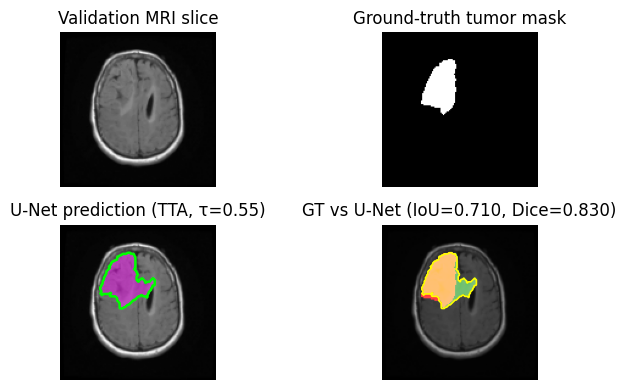

In [53]:
# ============================================================================
# 6.1 Single-Sample Evaluation (Visual Sanity Check)
# ============================================================================
# Before computing bulk metrics, let's visually inspect the model's output
# on a single validation sample. This is a crucial "smell test" — if the
# model looks completely wrong here, something is probably broken.

unet.eval()

# Find a non-empty validation sample (one that actually has a tumor)
non_empty_val_indices = []
for idx, (_, mask_p) in enumerate(val_pairs):
    if has_foreground(mask_p):
        non_empty_val_indices.append(idx)

if non_empty_val_indices:
    ind_val = random.choice(non_empty_val_indices)
else:
    ind_val = random.randint(0, len(val_ds) - 1)

image_val, mask_val = val_ds[ind_val]

# Run inference with TTA (4-fold flip augmentation)
prob_val = predict_prob_with_tta(unet, image_val, unet_device, use_tta=True)

# ── Quick threshold search on this single sample ──
# Try several thresholds and pick the one with the best Dice
threshold_candidates = [0.35, 0.4, 0.45, 0.5, 0.55]
gt_unet = mask_val[0].numpy() > 0.5
best_thresh = 0.5
best_dice = -1.0
best_pred = None

for t in threshold_candidates:
    pred_t = prob_val > t
    dice_t = (2 * np.logical_and(pred_t, gt_unet).sum()) / np.clip(
        pred_t.sum() + gt_unet.sum(), 1, None
    )
    if dice_t > best_dice:
        best_dice = dice_t
        best_thresh = t
        best_pred = pred_t

pred_unet = best_pred
image_unet = image_val[0].numpy()

# Compute metrics for the selected threshold
iou_unet = (np.logical_and(pred_unet, gt_unet).sum() / 
            np.clip(np.logical_or(pred_unet, gt_unet).sum(), 1, None))
dice_unet = (2 * np.logical_and(pred_unet, gt_unet).sum() / 
             np.clip(pred_unet.sum() + gt_unet.sum(), 1, None))

print(f"📊 Single-sample evaluation (val index {ind_val}):")
print(f"   Selected threshold: {best_thresh:.2f}")
print(f"   IoU:  {iou_unet:.4f}")
print(f"   Dice: {dice_unet:.4f}")

# ── Visualize ──
fig, axes = plt.subplots(2, 2, figsize=(8, 4))

axes[0, 0].imshow(image_unet, cmap="gray")
axes[0, 0].set_title(f"Validation MRI slice")
axes[0, 0].axis("off")

axes[0, 1].imshow(gt_unet, cmap="gray")
axes[0, 1].set_title("Ground-truth tumor mask")
axes[0, 1].axis("off")

axes[1, 0].imshow(image_unet, cmap="gray")
axes[1, 0].imshow(np.ma.masked_where(~pred_unet, pred_unet), cmap="spring", alpha=0.45)
axes[1, 0].contour(pred_unet.astype(np.uint8), levels=[0.5], colors="lime", linewidths=1.8)
axes[1, 0].set_title(f"U-Net prediction (TTA, τ={best_thresh:.2f})")
axes[1, 0].axis("off")

# Overlay: Red = ground truth, Green = prediction, Yellow = overlap (correct)
overlay_unet = np.stack([image_unet, image_unet, image_unet], axis=-1)
overlay_unet[..., 0] = np.where(gt_unet, 1.0, overlay_unet[..., 0])
overlay_unet[..., 1] = np.where(pred_unet, 1.0, overlay_unet[..., 1])
axes[1, 1].imshow(overlay_unet)
axes[1, 1].imshow(np.ma.masked_where(~pred_unet, pred_unet), cmap="spring", alpha=0.25)
axes[1, 1].contour(pred_unet.astype(np.uint8), levels=[0.5], colors="yellow", linewidths=1.2)
axes[1, 1].set_title(f"GT vs U-Net (IoU={iou_unet:.3f}, Dice={dice_unet:.3f})")
axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig('images/unet_res_index_{}.png'.format(ind_val), dpi=150)
plt.show()

---

## Part 6: Evaluation — How Good Is Our Model?

Evaluation in medical imaging must be **thorough and multi-level:**

| Level | What it tells us | Risk if skipped |
|---|---|---|
| **Single sample** | Visual sanity check | Might miss obvious bugs |
| **Slice-level metrics** | Average performance across slices | Hides per-patient variability |
| **Patient-level metrics** | Performance aggregated by patient | Reveals if model fails for specific patients |
| **Failure analysis** | Visual inspection of worst cases | Might miss dangerous failure modes |

> ⚠️ **Key principle:** A model with great *average* metrics can still fail catastrophically on individual patients. Always check the distribution tails.

### 6.2 Full Validation Report — Threshold Optimization & Metrics

Now we evaluate across **all** non-empty validation slices and find the **globally optimal threshold.**

**Why search for the best threshold?**
- The model outputs probabilities in [0, 1]
- We need to pick a cutoff (τ): probability > τ → "tumor"
- Too low τ → many false positives (over-segmentation)
- Too high τ → many false negatives (under-segmentation)
- We search over τ ∈ {0.30, 0.35, 0.40, ..., 0.70} and pick the one with the best **mean Dice**

**Metrics explained:**
- **IoU** (Intersection over Union): strict — penalizes both FP and FN equally
- **Dice** (F1): overlap quality — the standard metric in medical segmentation competitions

Evaluating on 96 non-empty validation slices...

  VALIDATION RESULTS
  Non-empty validation slices: 96
  Best global threshold:       0.40
──────────────────────────────────────────────────
  IoU:  mean=0.6868  median=0.7578  std=0.2275
  Dice: mean=0.7860  median=0.8622  std=0.2139
──────────────────────────────────────────────────
  Dice ≥ 0.50: 89.6% of slices
  Dice ≥ 0.70: 81.2% of slices


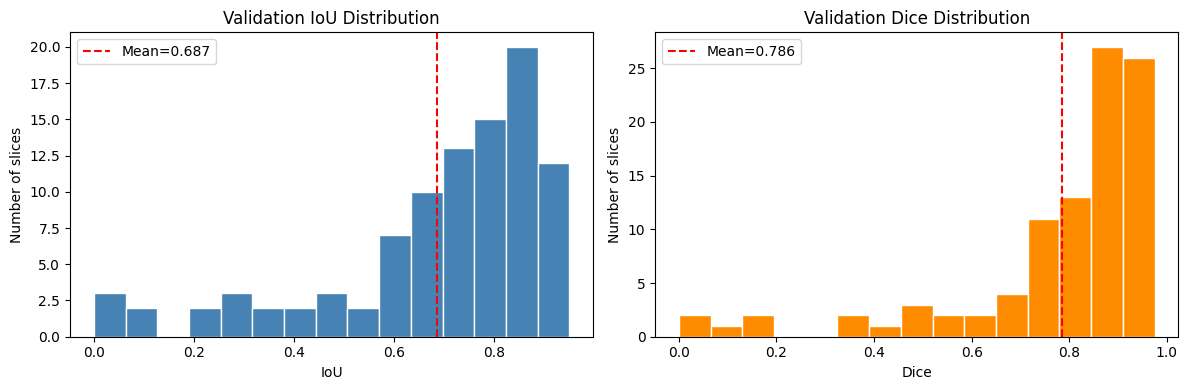


📝 Note: Look at the LEFT TAIL of the distributions — those are the problematic slices.
   A long left tail suggests the model struggles with certain cases.


In [54]:
# ============================================================================
# 6.2 Full Validation Report with Threshold Grid Search
# ============================================================================

unet.eval()

# Identify all validation slices that contain tumor
report_indices = [i for i, (_, mask_p) in enumerate(val_pairs) if has_foreground(mask_p)]
if not report_indices:
    raise RuntimeError("No non-empty validation masks found.")

print(f"Evaluating on {len(report_indices)} non-empty validation slices...")

# ── Threshold grid search ──
# For each candidate threshold, compute IoU and Dice on all samples
threshold_grid = np.arange(0.30, 0.71, 0.05)

def compute_metrics_for_threshold(threshold):
    """Compute IoU and Dice for all non-empty validation slices at a given threshold."""
    ious, dices = [], []
    for idx in report_indices:
        image_val, mask_val = val_ds[idx]
        prob_val = predict_prob_with_tta(unet, image_val, unet_device, use_tta=True)

        pred = prob_val > threshold
        gt = mask_val[0].numpy() > 0.5

        iou = np.logical_and(pred, gt).sum() / np.clip(np.logical_or(pred, gt).sum(), 1, None)
        dice = (2 * np.logical_and(pred, gt).sum()) / np.clip(pred.sum() + gt.sum(), 1, None)

        ious.append(float(iou))
        dices.append(float(dice))

    return np.array(ious), np.array(dices)


# Find the threshold that maximizes mean Dice
best_threshold = None
best_mean_dice = -1.0
best_ious = None
best_dices = None

for thr_candidate in threshold_grid:
    ious_c, dices_c = compute_metrics_for_threshold(float(thr_candidate))
    mean_dice_c = float(dices_c.mean())
    if mean_dice_c > best_mean_dice:
        best_mean_dice = mean_dice_c
        best_threshold = float(thr_candidate)
        best_ious = ious_c
        best_dices = dices_c

# ── Print results ──
print(f"\n{'='*50}")
print(f"  VALIDATION RESULTS")
print(f"{'='*50}")
print(f"  Non-empty validation slices: {len(report_indices)}")
print(f"  Best global threshold:       {best_threshold:.2f}")
print(f"{'─'*50}")
print(f"  IoU:  mean={best_ious.mean():.4f}  median={np.median(best_ious):.4f}  std={best_ious.std():.4f}")
print(f"  Dice: mean={best_dices.mean():.4f}  median={np.median(best_dices):.4f}  std={best_dices.std():.4f}")
print(f"{'─'*50}")
print(f"  Dice ≥ 0.50: {(best_dices >= 0.50).mean() * 100:.1f}% of slices")
print(f"  Dice ≥ 0.70: {(best_dices >= 0.70).mean() * 100:.1f}% of slices")
print(f"{'='*50}")

# ── Distribution plots ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(best_ious, bins=15, color="steelblue", edgecolor="white")
axes[0].axvline(best_ious.mean(), color="red", linestyle="--", label=f"Mean={best_ious.mean():.3f}")
axes[0].set_title("Validation IoU Distribution")
axes[0].set_xlabel("IoU")
axes[0].set_ylabel("Number of slices")
axes[0].legend()

axes[1].hist(best_dices, bins=15, color="darkorange", edgecolor="white")
axes[1].axvline(best_dices.mean(), color="red", linestyle="--", label=f"Mean={best_dices.mean():.3f}")
axes[1].set_title("Validation Dice Distribution")
axes[1].set_xlabel("Dice")
axes[1].set_ylabel("Number of slices")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📝 Note: Look at the LEFT TAIL of the distributions — those are the problematic slices.")
print("   A long left tail suggests the model struggles with certain cases.")

### 6.3 Per-Patient Validation Summary

**Why patient-level matters more than slice-level:**

In clinical practice, decisions are made **per patient**, not per slice. A model might achieve great average slice metrics while consistently failing on a specific patient (e.g., due to unusual tumor location or scanner artifacts).

Patient-level aggregation reveals:
- **Consistency:** Is the model reliable across different patients?
- **Failure patterns:** Are there specific patient types where it struggles?
- **Clinical readiness:** Would a radiologist trust this model's output for every patient?

In [55]:
# ============================================================================
# 6.3 Per-Patient Validation Report
# ============================================================================
# Group slices by patient and compute mean metrics per patient.
# This gives a more clinically meaningful view of model performance.

unet.eval()

# Use the globally optimized threshold from section 6.2
try:
    threshold_for_patient_report = float(best_threshold)
except NameError:
    threshold_for_patient_report = 0.5

# ── Group slices by patient ID ──
# Patient ID is derived from the directory name (e.g., "TCGA_CS_4941_19960909")
patient_to_indices = {}
for idx in report_indices:
    image_path_i, _ = val_pairs[idx]
    patient_id = os.path.basename(os.path.dirname(image_path_i))
    patient_to_indices.setdefault(patient_id, []).append(idx)

print(f"Computing per-patient metrics (threshold={threshold_for_patient_report:.2f})...\n")

# ── Compute metrics for each patient ──
patient_rows = []

for patient_id, indices in patient_to_indices.items():
    ious, dices = [], []
    for idx in indices:
        image_val, mask_val = val_ds[idx]
        prob_val = predict_prob_with_tta(unet, image_val, unet_device, use_tta=True)

        pred = prob_val > threshold_for_patient_report
        gt = mask_val[0].numpy() > 0.5

        iou = np.logical_and(pred, gt).sum() / np.clip(np.logical_or(pred, gt).sum(), 1, None)
        dice = (2 * np.logical_and(pred, gt).sum()) / np.clip(pred.sum() + gt.sum(), 1, None)

        ious.append(float(iou))
        dices.append(float(dice))

    patient_rows.append({
        "patient_id": patient_id,
        "n_slices": len(indices),
        "mean_iou": float(np.mean(ious)),
        "mean_dice": float(np.mean(dices)),
    })

# Sort by performance (best to worst)
patient_rows = sorted(patient_rows, key=lambda x: x["mean_dice"], reverse=True)

patient_mean_ious = np.array([r["mean_iou"] for r in patient_rows])
patient_mean_dices = np.array([r["mean_dice"] for r in patient_rows])

# ── Print results ──
print(f"{'='*50}")
print(f"  PER-PATIENT RESULTS ({len(patient_rows)} patients)")
print(f"{'='*50}")
print(f"  Patient-mean IoU (macro):    {patient_mean_ious.mean():.4f}")
print(f"  Patient-median IoU:          {np.median(patient_mean_ious):.4f}")
print(f"  Patient-mean Dice (macro):   {patient_mean_dices.mean():.4f}")
print(f"  Patient-median Dice:         {np.median(patient_mean_dices):.4f}")

print(f"\n  🏆 Top 5 patients:")
for r in patient_rows[:5]:
    print(f"     {r['patient_id']}: Dice={r['mean_dice']:.4f}, IoU={r['mean_iou']:.4f} ({r['n_slices']} slices)")

print(f"\n  ⚠️  Bottom 5 patients:")
for r in patient_rows[-5:]:
    print(f"     {r['patient_id']}: Dice={r['mean_dice']:.4f}, IoU={r['mean_iou']:.4f} ({r['n_slices']} slices)")

print(f"\n📝 The GAP between top and bottom patients indicates model consistency.")

Computing per-patient metrics (threshold=0.40)...

  PER-PATIENT RESULTS (61 patients)
  Patient-mean IoU (macro):    0.6802
  Patient-median IoU:          0.7273
  Patient-mean Dice (macro):   0.7819
  Patient-median Dice:         0.8383

  🏆 Top 5 patients:
     TCGA_DU_6404_19850629: Dice=0.9732, IoU=0.9479 (2 slices)
     TCGA_HT_8111_19980330: Dice=0.9618, IoU=0.9265 (1 slices)
     TCGA_CS_6666_20011109: Dice=0.9507, IoU=0.9061 (1 slices)
     TCGA_HT_8105_19980826: Dice=0.9473, IoU=0.8998 (1 slices)
     TCGA_HT_7692_19960724: Dice=0.9439, IoU=0.8937 (2 slices)

  ⚠️  Bottom 5 patients:
     TCGA_DU_5874_19950510: Dice=0.4279, IoU=0.2722 (1 slices)
     TCGA_CS_6667_20011105: Dice=0.3602, IoU=0.2197 (1 slices)
     TCGA_HT_8114_19981030: Dice=0.3362, IoU=0.2021 (1 slices)
     TCGA_HT_A61A_20000127: Dice=0.2204, IoU=0.1646 (3 slices)
     TCGA_DU_A5TP_19970614: Dice=0.0870, IoU=0.0455 (1 slices)

📝 The GAP between top and bottom patients indicates model consistency.


### 6.4 Failure Analysis — Learning from the Worst Cases

> 🔍 **This is arguably the most important section of the notebook.**

Failure analysis helps us understand *why* the model makes mistakes, which informs:
- Which patients/cases need extra attention
- Whether the model is safe enough for its intended use
- What improvements to pursue next (more data? different architecture? better augmentation?)

**Questions to ask when looking at failure cases:**
1. Is the tumor very small or faint? → The model may struggle with low signal-to-noise
2. Is the tumor at an unusual location? → May need more diverse training data
3. Does the model under-segment or over-segment? → Suggests loss/threshold tuning
4. Is the ground-truth annotation ambiguous? → Even experts disagree on boundaries

🔍 Worst 3 patients by mean Dice:
   TCGA_DU_A5TP_19970614: Dice=0.0870, IoU=0.0455 (1 slices)
   TCGA_HT_A61A_20000127: Dice=0.2204, IoU=0.1646 (3 slices)
   TCGA_HT_8114_19981030: Dice=0.3362, IoU=0.2021 (1 slices)



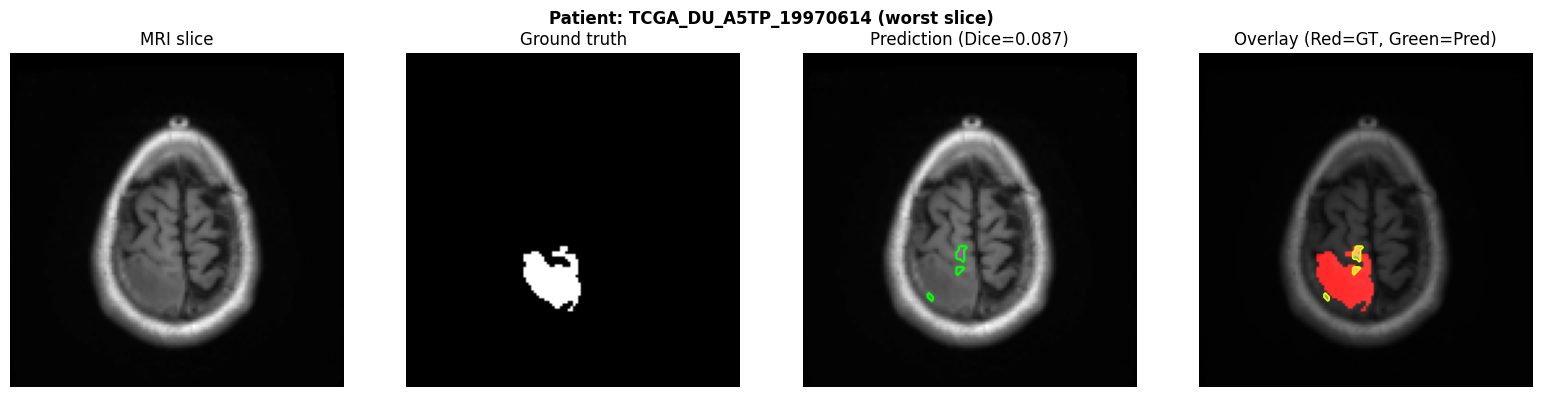

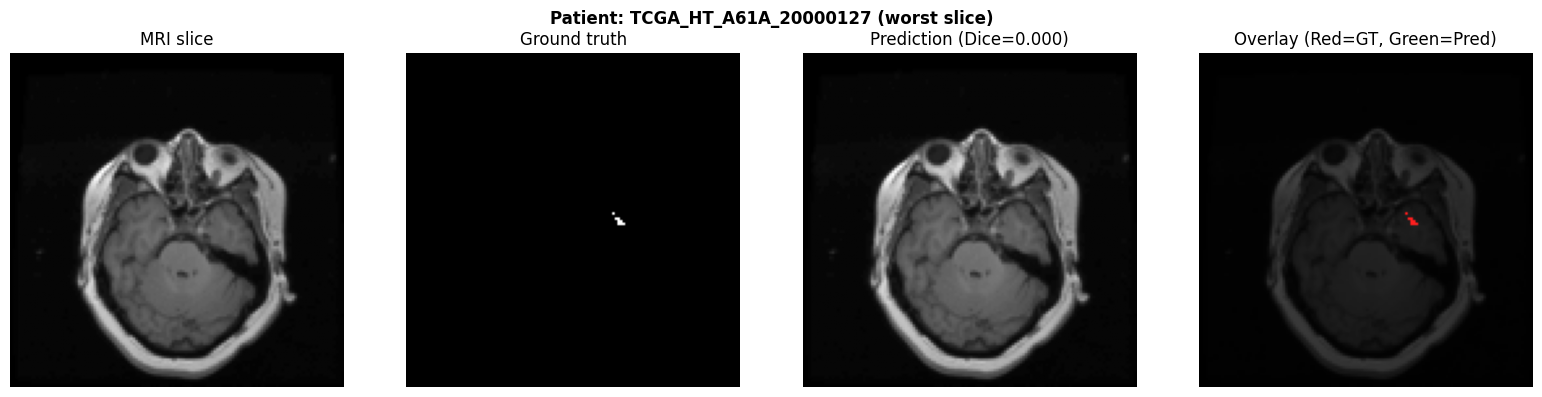

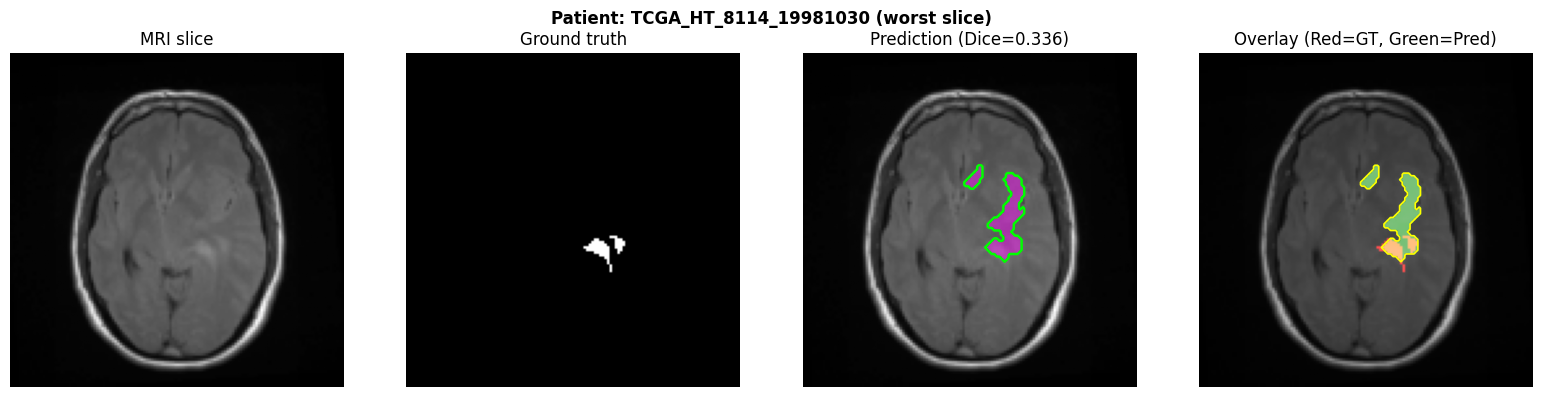

In [56]:
# ============================================================================
# 6.4 Visual Diagnostics for the 3 Worst-Performing Patients
# ============================================================================

unet.eval()

if "patient_rows" not in globals() or len(patient_rows) == 0:
    raise RuntimeError("Run the per-patient validation report cell first.")

# Get the 3 patients with the lowest mean Dice score
worst_patients = sorted(patient_rows, key=lambda x: x["mean_dice"])[:3]

print("🔍 Worst 3 patients by mean Dice:")
for p in worst_patients:
    print(f"   {p['patient_id']}: Dice={p['mean_dice']:.4f}, IoU={p['mean_iou']:.4f} ({p['n_slices']} slices)")
print()

for p in worst_patients:
    pid = p["patient_id"]
    indices = patient_to_indices[pid]

    # Find the WORST single slice for this patient (most representative failure)
    rep_dice = float("inf")
    rep_iou = 0.0
    rep_image = rep_gt = rep_pred = None

    for idx in indices:
        image_val, mask_val = val_ds[idx]
        prob_val = predict_prob_with_tta(unet, image_val, unet_device, use_tta=True)

        pred = prob_val > threshold_for_patient_report
        gt = mask_val[0].numpy() > 0.5

        iou = np.logical_and(pred, gt).sum() / np.clip(np.logical_or(pred, gt).sum(), 1, None)
        dice = (2 * np.logical_and(pred, gt).sum()) / np.clip(pred.sum() + gt.sum(), 1, None)

        if dice < rep_dice:
            rep_dice = float(dice)
            rep_iou = float(iou)
            rep_image = image_val[0].numpy()
            rep_gt = gt
            rep_pred = pred

    # ── Visualize the worst slice for this patient ──
    overlay = np.stack([rep_image, rep_image, rep_image], axis=-1)
    overlay[..., 0] = np.where(rep_gt, 1.0, overlay[..., 0])       # Red = GT
    overlay[..., 1] = np.where(rep_pred, 1.0, overlay[..., 1])     # Green = Pred

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"Patient: {pid} (worst slice)", fontsize=12, fontweight="bold")
    
    axes[0].imshow(rep_image, cmap="gray")
    axes[0].set_title("MRI slice")
    axes[0].axis("off")

    axes[1].imshow(rep_gt, cmap="gray")
    axes[1].set_title("Ground truth")
    axes[1].axis("off")

    axes[2].imshow(rep_image, cmap="gray")
    axes[2].imshow(np.ma.masked_where(~rep_pred, rep_pred), cmap="spring", alpha=0.45)
    axes[2].contour(rep_pred.astype(np.uint8), levels=[0.5], colors="lime", linewidths=1.8)
    axes[2].set_title(f"Prediction (Dice={rep_dice:.3f})")
    axes[2].axis("off")

    axes[3].imshow(overlay)
    axes[3].imshow(np.ma.masked_where(~rep_pred, rep_pred), cmap="spring", alpha=0.25)
    axes[3].contour(rep_pred.astype(np.uint8), levels=[0.5], colors="yellow", linewidths=1.2)
    axes[3].set_title(f"Overlay (Red=GT, Green=Pred)")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

---

## Part 7: Clinical Caveats and Responsible AI

> ⚠️ Before any model leaves a research notebook, these questions must be answered honestly.

### Known Limitations

| Limitation | Impact | Mitigation |
|---|---|---|
| **2D slice-based** | Ignores 3D spatial continuity | Use 3D U-Net or post-processing across slices |
| **Single dataset** | May not generalize to other scanners/sites | External validation on independent datasets |
| **Binary segmentation** | Cannot distinguish tumor subtypes | Multi-class segmentation with more labels |
| **Annotation variability** | Ground-truth masks may have inter-observer disagreement | Consensus annotations, multiple raters |
| **No calibration analysis** | Probability outputs may not reflect true confidence | Calibration curves, Platt scaling |

### Responsible Use Checklist

- [ ] Model validated on external, independent dataset
- [ ] Failure modes documented and communicated to users
- [ ] Model outputs always reviewed by qualified clinician
- [ ] Regulatory requirements met (e.g., FDA clearance for clinical use)
- [ ] Bias assessment performed (demographics, scanner types)
- [ ] Patient privacy protected (no identifiable data leakage)

**Take-home message:** Good validation metrics are *necessary* but **not sufficient** for medical deployment.

### Model Card (One-Slide Summary)

> A "Model Card" (Mitchell et al., 2019) is a standardized document describing a model's intended use, performance, and limitations. Every ML model should have one.

| Field | Details |
|---|---|
| **Model** | Residual SE U-Net (2D slice segmentation) |
| **Input** | Grayscale brain MRI slice (128 × 128) |
| **Output** | Tumor probability map + thresholded binary mask |
| **Training data** | LGG MRI Segmentation (110 patients, Kaggle) |
| **Training strategy** | BCE + Focal-Tversky loss, EMA, TTA, weighted sampling |

| **Intended use** | **NOT intended for** |
|---|---|
| Educational demonstration | Clinical diagnosis |
| Medical segmentation tutorials | Treatment planning |
| Research prototyping | Autonomous decision-making |

| **Strengths** | **Limitations** |
|---|---|
| Imbalance-aware training | 2D only (no 3D context) |
| EMA + TTA for robustness | Single dataset/domain |
| Patient-level evaluation | No calibration analysis |
| Failure analysis included | Potential annotation variability |

---

## Part 8: Save Model Checkpoint

Save the trained model for later use (e.g., in the web application or for ONNX export).

In [57]:
# ============================================================================
# 8.1 Save and Verify Model Checkpoint
# ============================================================================
# The checkpoint contains everything needed to reproduce the model:
#   - model_state_dict: raw model weights
#   - ema_state_dict: smoothed EMA weights (used for inference)
#   - model_class: architecture name (for loading logic)
#   - base_ch: base channel count (architecture parameter)
#   - img_size: input image resolution
#   - threshold: optimal classification threshold from validation
#   - best_val_loss: validation loss of the saved model

import os
import torch

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "unet_resse_best.pt")

# ── Build checkpoint dictionary ──
checkpoint = {
    "model_state_dict": unet.state_dict(),
    "model_class": "SmallUNet",
    "base_ch": 64,
    "img_size": IMG_SIZE,
    "best_val_loss": float(best_val_loss) if "best_val_loss" in globals() else None,
    "threshold": float(best_threshold) if "best_threshold" in globals() and best_threshold is not None else 0.5,
}

# Include EMA weights if available (these are typically used for inference)
if "ema" in globals():
    checkpoint["ema_state_dict"] = {k: v.detach().cpu() for k, v in ema.shadow.items()}

# ── Save ──
torch.save(checkpoint, checkpoint_path)
print(f"💾 Checkpoint saved to: {checkpoint_path}")
print(f"   Model class:  {checkpoint['model_class']}")
print(f"   Image size:   {checkpoint['img_size']}")
print(f"   Threshold:    {checkpoint['threshold']:.2f}")

# ── Verify by loading into a fresh model ──
print(f"\n🔍 Verifying checkpoint...")
loaded_checkpoint = torch.load(checkpoint_path, map_location=unet_device)
loaded_unet = SmallUNet(base_ch=loaded_checkpoint.get("base_ch", 48)).to(unet_device)
loaded_unet.load_state_dict(loaded_checkpoint["model_state_dict"])
loaded_unet.eval()

print(f"✅ Checkpoint verified — loaded successfully!")
print(f"   Threshold:    {loaded_checkpoint.get('threshold', 0.5):.2f}")
print(f"\n📌 Next steps:")
print(f"   • Run 'python export_onnx.py' to convert to ONNX for web deployment")
print(f"   • See the brain_app/ directory for the Django web application")

💾 Checkpoint saved to: checkpoints\unet_resse_best.pt
   Model class:  SmallUNet
   Image size:   128
   Threshold:    0.40

🔍 Verifying checkpoint...
✅ Checkpoint verified — loaded successfully!
   Threshold:    0.40

📌 Next steps:
   • Run 'python export_onnx.py' to convert to ONNX for web deployment
   • See the brain_app/ directory for the Django web application
